# 03 · The mood of music over time

**The question:** does the emotional tone of music shift across the century — and if so, *which* tone? 'Mood' isn't one number. We treat it as **several near-independent axes** and check each:

1. The continuous signals — `valence`, `energy`, `danceability` — over time.
2. A second, tonal axis we've ignored so far: **major vs minor key** (`mode`).
3. Are those axes even measuring the same thing? (they mostly aren't)
4. Is the valence decline *real*, or just the **genre mix** changing underneath us?
5. Supporting textures — the loudness war, explicit lyrics, song length.
6. The whole path through mood-space, with tonality folded in.
7. Does music's mood track the **nation's** mood? (an external misery-index overlay)

Everything here is *correlational*; we flag confounds as we go.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'analysis'))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
from common import load_genre, load_timeline, AUDIO, zscore
from common import attach_genre, load_misery, load_sentiment   # used only in this notebook
df = load_timeline()
EVENTS = {1929:'Depression', 1945:'WWII ends', 1969:'Woodstock', 1981:'MTV',
          2008:'Financial crisis', 2020:'COVID'}
n_by_year = df.groupby('year').size()
yr = df.groupby('year')[['valence','energy','danceability']].mean()
yr.tail(3)

,valence,energy,danceability
year,,,
2019,0.494212,0.637066,0.649724
2020,0.501712,0.639669,0.657129
2021,0.506228,0.617998,0.671531


## Step 1 — Three emotional signals across a century
The classic mood features. The lower strip shows how many tracks back each year: the catalog is thin before ~1950, so read the far-left wiggles cautiously.

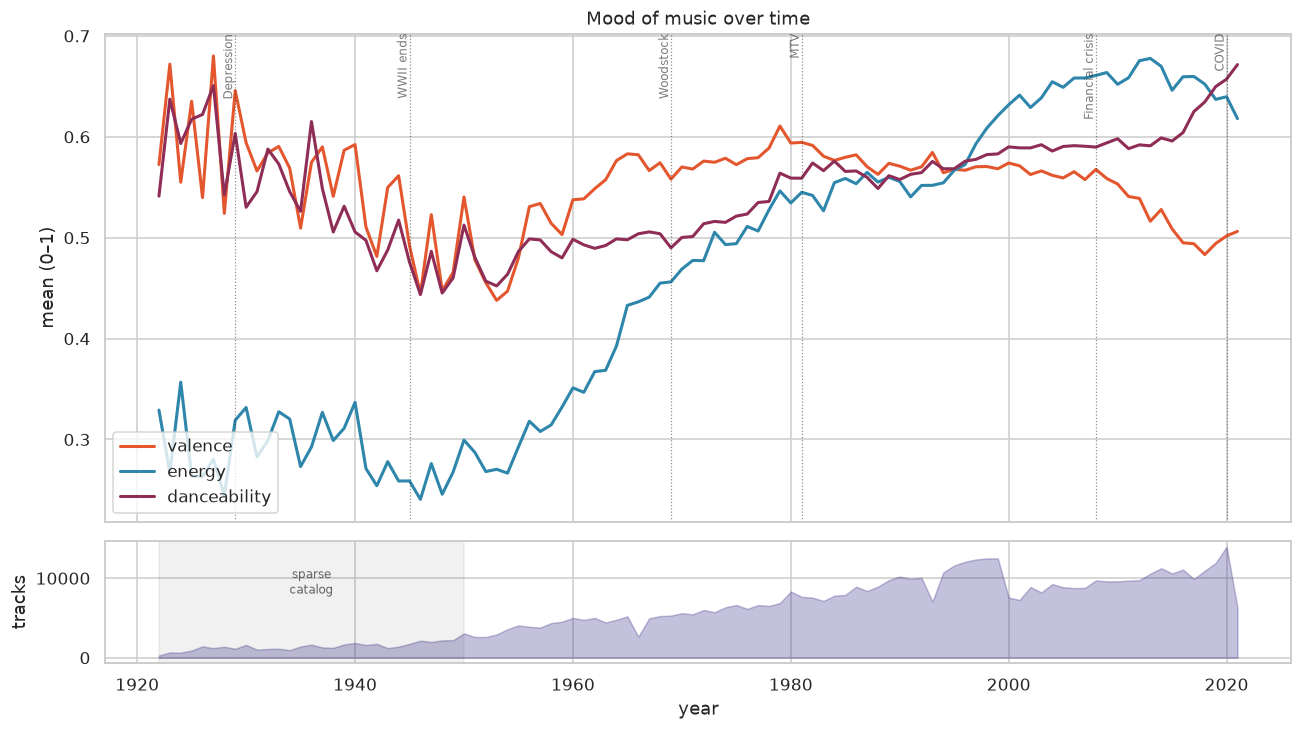

In [2]:
fig, (ax, axn) = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True,
                              gridspec_kw={'height_ratios': [4, 1]})
for f, c in [('valence','#e4572e'), ('energy','#2e86ab'), ('danceability','#8f2d56')]:
    ax.plot(yr.index, yr[f], label=f, color=c, lw=2)
top = ax.get_ylim()[1]
for y0, name in EVENTS.items():
    ax.axvline(y0, color='k', ls=':', lw=.8, alpha=.5)
    ax.text(y0, top, name, rotation=90, va='top', ha='right', fontsize=8, alpha=.6)
ax.set_ylabel('mean (0–1)'); ax.legend(loc='lower left')
ax.set_title('Mood of music over time')
axn.fill_between(n_by_year.index, n_by_year.values, color='#3d348b', alpha=.3)
axn.axvspan(df.year.min(), 1950, color='k', alpha=.06)
axn.text(1936, axn.get_ylim()[1]*.55, 'sparse\ncatalog', fontsize=8, ha='center', alpha=.7)
axn.set_ylabel('tracks'); axn.set_xlabel('year'); plt.tight_layout(); plt.show()

The whole *distribution* per decade (not just the mean) for every **continuous** mood/texture metric we examine later. Read down each column: energy and loudness shift wholesale, valence sags gently, tempo creeps up, songs lengthen then shrink. (The 0/1 flags — minor-key and explicit shares — get their own plots below; a violin of a binary flag is meaningless.)

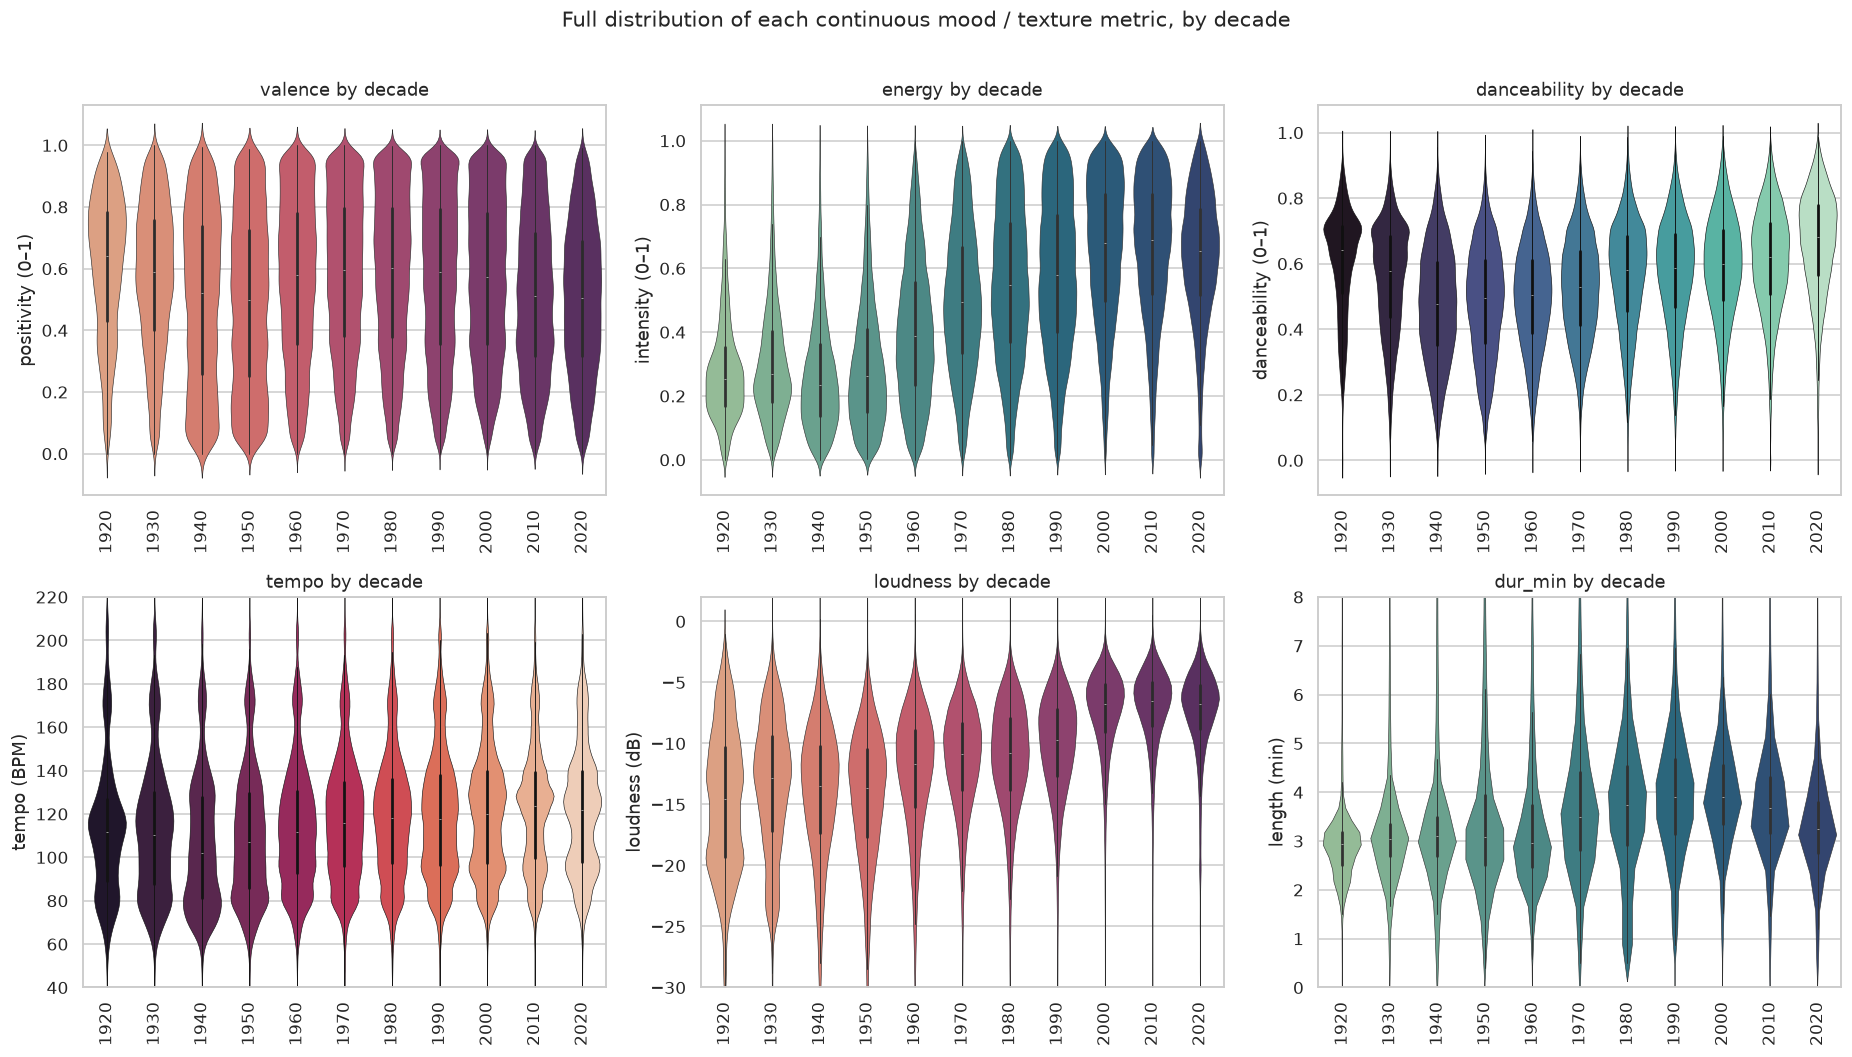

In [3]:
dv = df.assign(decade=df.decade.astype(str), dur_min=df.duration_ms/60000)
order = [str(d) for d in sorted(df.decade.unique())]
panels = [('valence','flare','positivity (0–1)', None),
          ('energy','crest','intensity (0–1)', None),
          ('danceability','mako','danceability (0–1)', None),
          ('tempo','rocket','tempo (BPM)', (40, 220)),
          ('loudness','flare','loudness (dB)', (-30, 2)),
          ('dur_min','crest','length (min)', (0, 8))]
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
for ax, (f, cmap, ylab, ylim) in zip(axes.ravel(), panels):
    sns.violinplot(dv, x='decade', y=f, order=order, ax=ax, hue='decade', hue_order=order,
                   legend=False, density_norm='width', linewidth=.4, palette=cmap)
    ax.set_title(f'{f} by decade'); ax.set_xlabel(''); ax.set_ylabel(ylab)
    if ylim: ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=90)
fig.suptitle('Full distribution of each continuous mood / texture metric, by decade',
             y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## Step 2 — The second axis: are we writing in minor keys?
`mode` = 1 for major (the 'bright' tonality), 0 for minor (the 'dark' one). It's the most direct tonal cue for sad-vs-happy, and we hadn't touched it. The share of tracks written in a **minor** key has climbed steadily for a century — a cleaner trend than valence.

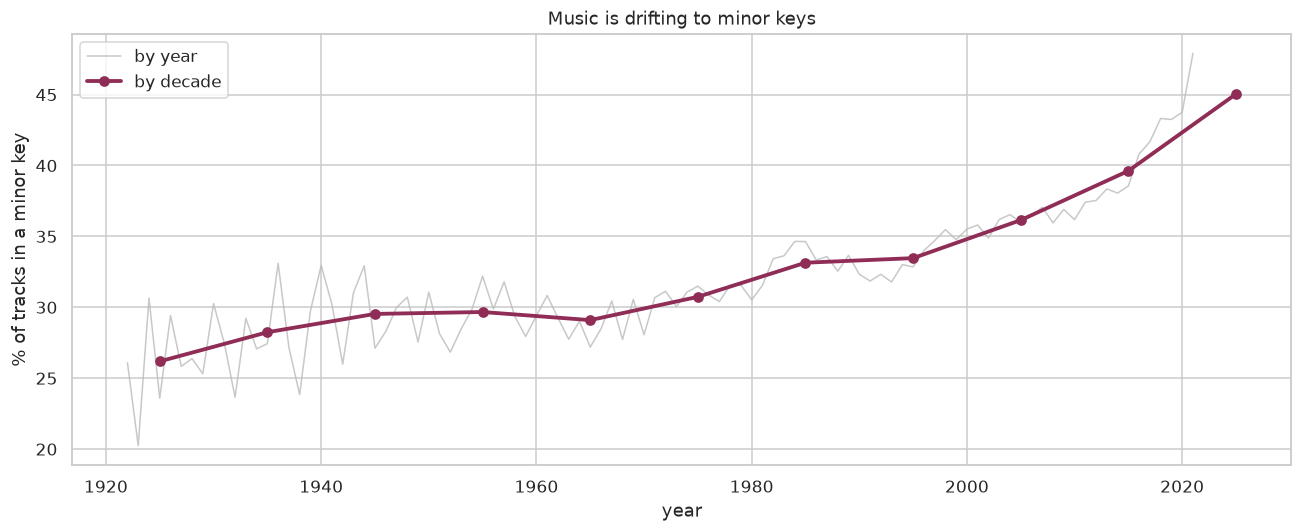

minor-key share: 26% (1920s) -> 45% (2020s)   corr with year = 0.85


In [4]:
minor_yr = 1 - df.groupby('year')['mode'].mean()     # mode is 1=major/0=minor,
minor_dec = 1 - df.groupby('decade')['mode'].mean()   # so minor share = 1 - mean
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(minor_yr.index, minor_yr.values*100, color='#bbb', lw=1, alpha=.8, label='by year')
ax.plot(minor_dec.index+5, minor_dec.values*100, marker='o', color='#8f2d56', lw=2.5,
        label='by decade')
ax.set_ylabel('% of tracks in a minor key'); ax.set_xlabel('year')
ax.set_title('Music is drifting to minor keys'); ax.legend(); plt.tight_layout(); plt.show()
r = np.corrcoef(minor_yr.index, minor_yr.values)[0, 1]
print(f'minor-key share: {minor_dec.iloc[0]:.0%} (1920s) -> {minor_dec.iloc[-1]:.0%} (2020s)   corr with year = {r:.2f}')

## Step 3 — Are the mood axes even the same thing?
If valence, energy and tonality all measured 'happiness', they'd correlate. This track-level correlation matrix shows they **don't**: `valence` and `mode` are essentially uncorrelated (≈0) — minor-key music isn't reliably 'sad' by valence. So the minor-key rise and the valence sag are *two separate stories*, which is why we track them separately.

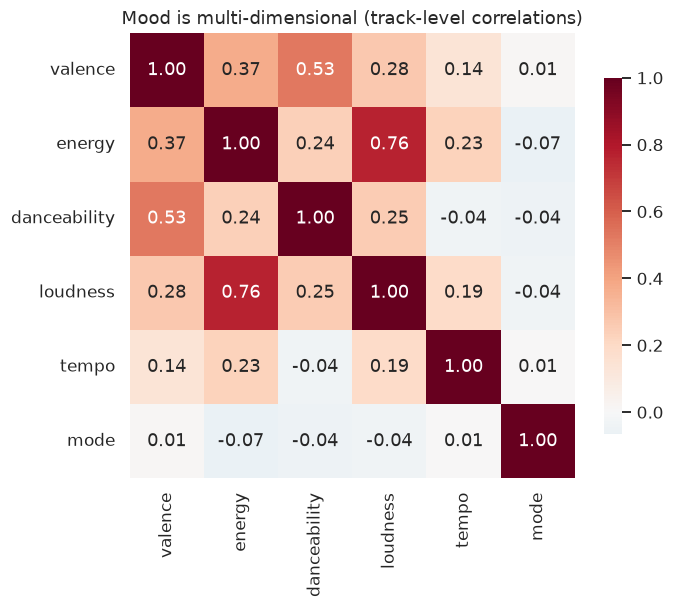

In [5]:
mood_cols = ['valence', 'energy', 'danceability', 'loudness', 'tempo', 'mode']
c = df[mood_cols].corr()
plt.figure(figsize=(6.8, 5.6))
sns.heatmap(c, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': .8})
plt.title('Mood is multi-dimensional (track-level correlations)')
plt.tight_layout(); plt.show()

## Step 4 — What's driving it: genres darkening, or the mix shifting?
Aggregate valence fell — but that can happen two genuinely different ways, and it's worth knowing which. Either **(a)** each genre's own music got sadder (a *within-genre* shift), or **(b)** the catalog reweighted toward genres that were already sadder (a *between-genre*, mix shift, as jazz/classical fade and hip-hop explodes). Both are real changes in the music people hear — neither is an 'artifact' — but they mean different things about *why* the sound of the era changed. To separate them we need a genre for dataset B, which has none: we borrow one by mapping each track's lead artist to its Spotify genres via `artists.csv` and bucketing into coarse **supergenres** (`attach_genre`; ~72% land in a named bucket, the rest 'other'), then split the change with a shift-share decomposition.

In [6]:
g = attach_genre(df)
sub = g[g.decade.isin([1960, 2010])]
per = sub.groupby(['decade', 'supergenre']).agg(v=('valence','mean'), n=('valence','size'))
d0, d1 = per.xs(1960), per.xs(2010)
MIN_N = 50   # need enough tracks in a (genre, decade) cell to trust its mean
both = [x for x in d0.index.intersection(d1.index)
        if d0.loc[x,'n'] >= MIN_N and d1.loc[x,'n'] >= MIN_N]
d0b, d1b = d0.loc[both], d1.loc[both]
w0, w1 = d0b.n/d0b.n.sum(), d1b.n/d1b.n.sum()   # genre weights per decade
# Shift-share (Oaxaca) decomposition of the aggregate valence change:
within  = (w0 * (d1b.v - d0b.v)).sum()          # mood shift, mix held at 1960s
between = ((w1 - w0) * d0b.v).sum()              # mix shift, mood held at 1960s
interact = ((w1 - w0) * (d1b.v - d0b.v)).sum()
agg0, agg1 = (w0*d0b.v).sum(), (w1*d1b.v).sum()
cov = (d0b.n.sum()+d1b.n.sum()) / (d0.n.sum()+d1.n.sum())
print(f'aggregate valence 1960s {agg0:.3f} -> 2010s {agg1:.3f}  (Δ {agg1-agg0:+.3f})')
print(f'  within-genre (real mood shift): {within:+.3f}')
print(f'  between-genre (mix changed)   : {between:+.3f}')
print(f'  interaction                   : {interact:+.3f}')
print(f'  [covers {cov:.0%} of both decades\' tracks]')

aggregate valence 1960s 0.562 -> 2010s 0.517  (Δ -0.044)
  within-genre (real mood shift): -0.057
  between-genre (mix changed)   : +0.020
  interaction                   : -0.007
  [covers 98% of both decades' tracks]


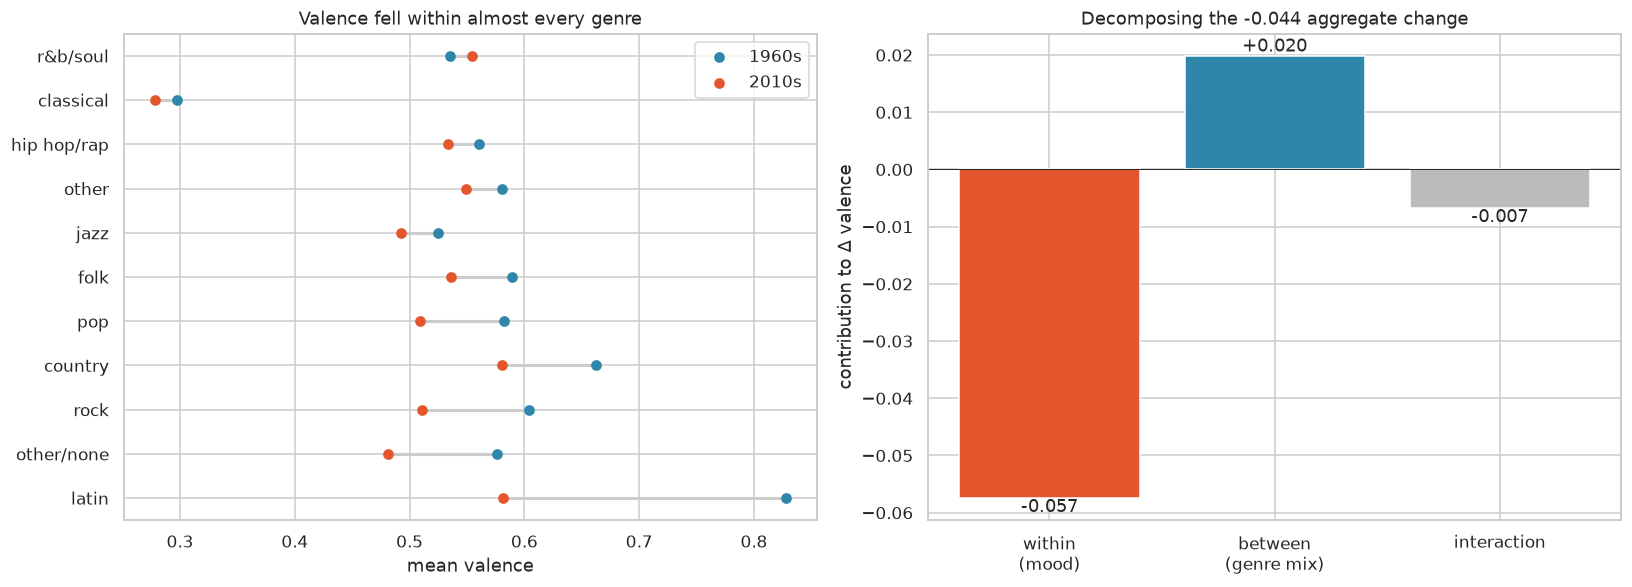

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ok = sorted(both, key=lambda x: d1b.loc[x,'v'] - d0b.loc[x,'v'])
for i, x in enumerate(ok):
    ax[0].plot([d0b.loc[x,'v'], d1b.loc[x,'v']], [i, i], color='#ccc', lw=2, zorder=1)
ax[0].scatter([d0b.loc[x,'v'] for x in ok], range(len(ok)), color='#2e86ab', label='1960s', zorder=2)
ax[0].scatter([d1b.loc[x,'v'] for x in ok], range(len(ok)), color='#e4572e', label='2010s', zorder=2)
ax[0].set_yticks(range(len(ok))); ax[0].set_yticklabels(ok)
ax[0].set_xlabel('mean valence'); ax[0].legend()
ax[0].set_title('Valence fell within almost every genre')
parts = pd.Series({'within\n(mood)': within, 'between\n(genre mix)': between,
                   'interaction': interact})
bars = ax[1].bar(parts.index, parts.values, color=['#e4572e','#2e86ab','#bbb'])
ax[1].axhline(0, color='k', lw=.6); ax[1].bar_label(bars, fmt='%+.3f')
ax[1].set_ylabel('contribution to Δ valence')
ax[1].set_title(f'Decomposing the {agg1-agg0:+.3f} aggregate change')
plt.tight_layout(); plt.show()

**Takeaway:** it's overwhelmingly the **within-genre** shift — valence fell *inside* almost every genre. The mix shift actually pushed the *other* way (+0.020: on balance the catalog drifted toward slightly *brighter* genres), so it **masks** part of the darkening — the within-genre drop (−0.057) is even bigger than the −0.044 aggregate. So 'music got sadder' isn't a composition trick: the songs themselves got sadder, genre by genre.

## Step 5 — Supporting textures
Three more columns that colour the story: the well-documented **loudness war**, the surge of **explicit** lyrics, and song **length** (rising through the album era, then falling as streaming rewards shorter tracks).

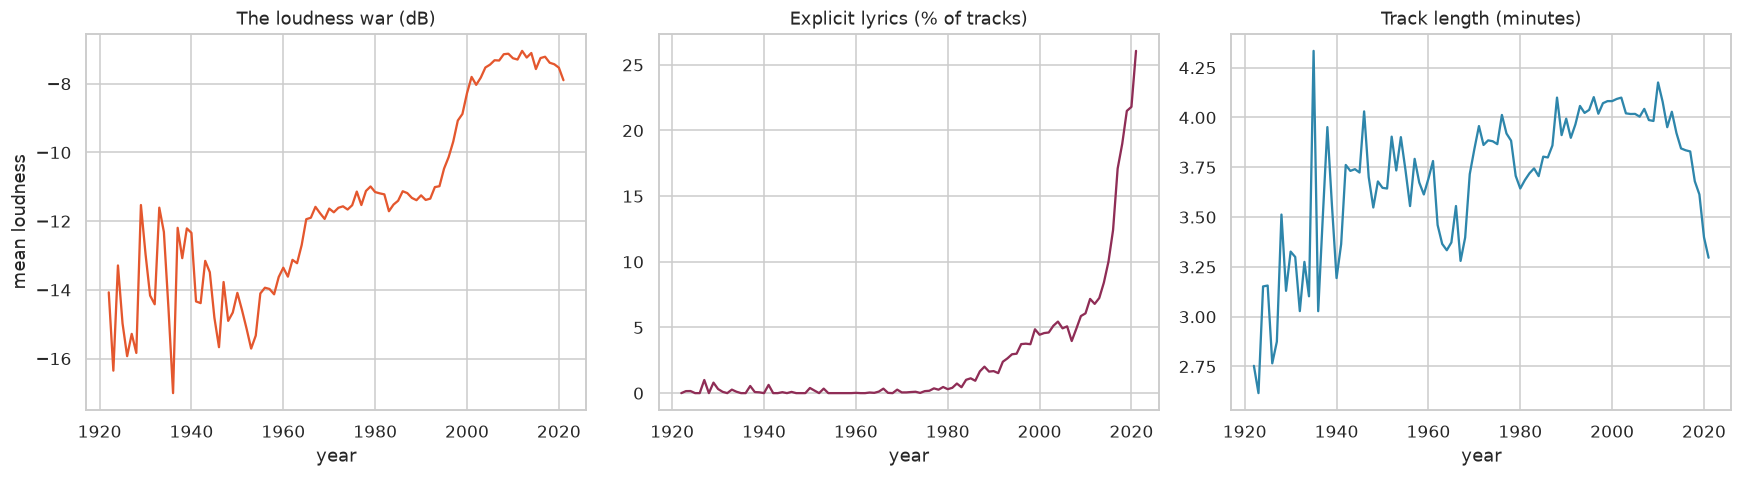

In [8]:
tex = df.assign(dur_min=df.duration_ms/60000)
by = tex.groupby('year').agg(loudness=('loudness','mean'), explicit=('explicit','mean'),
                             dur_min=('dur_min','mean'))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(by.index, by.loudness, color='#e4572e'); ax[0].set_title('The loudness war (dB)')
ax[0].set_ylabel('mean loudness')
ax[1].plot(by.index, by.explicit*100, color='#8f2d56')
ax[1].set_title('Explicit lyrics (% of tracks)')
ax[2].plot(by.index, by.dur_min, color='#2e86ab'); ax[2].set_title('Track length (minutes)')
for a in ax: a.set_xlabel('year')
plt.tight_layout(); plt.show()

## Step 6 — The path through mood-space (with tonality)
Each decade's average position on the valence×energy plane — the arrow of time drifting from *calm/positive* toward *intense*. Marker **size** now encodes minor-key share, so the tonal 'darkening' rides along with the energy climb.

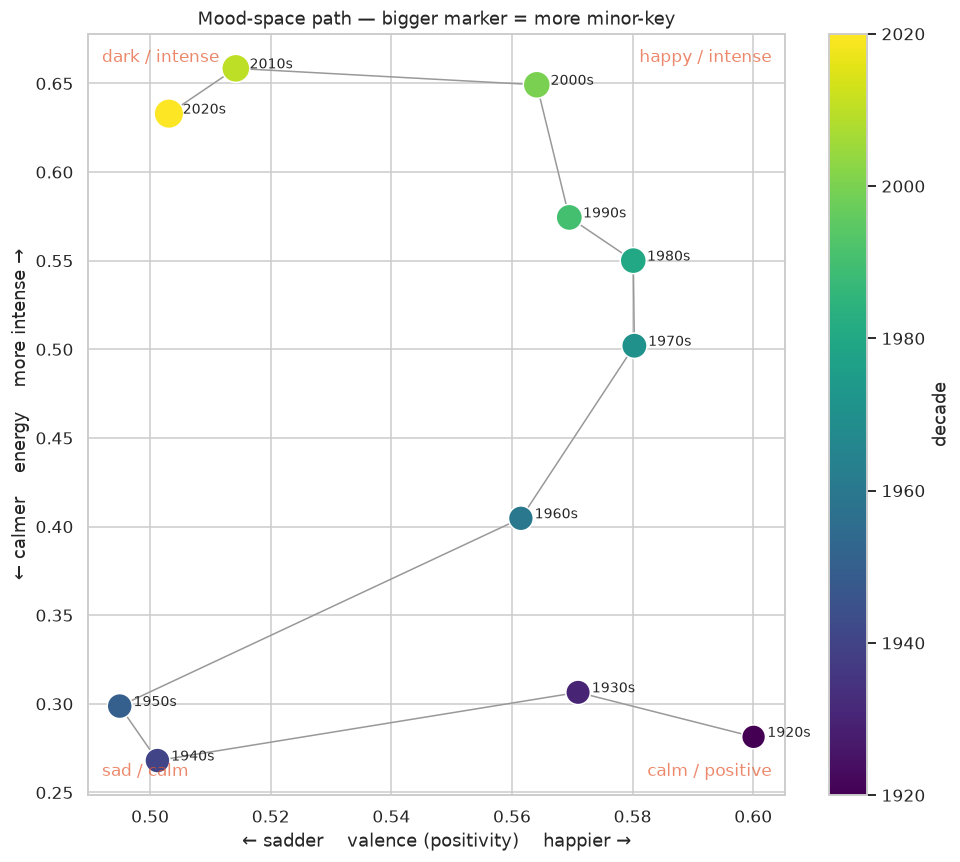

In [9]:
me = df.groupby('decade')[['valence','energy']].mean()
me['minor'] = minor_dec   # reuse the by-decade minor share from Step 2
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(me['valence'], me['energy'], '-', color='#999', lw=1, zorder=1)
sc = ax.scatter(me['valence'], me['energy'], c=me.index, cmap='viridis',
                s=60 + me['minor']*700, zorder=2, edgecolor='white')
for d, r in me.iterrows(): ax.annotate(f'{d}s', (r['valence'], r['energy']),
                                       textcoords='offset points', xytext=(9, 0), fontsize=9)
for q, xy, ha, va in [('calm / positive',(.98,.02),'right','bottom'),
                      ('happy / intense',(.98,.98),'right','top'),
                      ('sad / calm',(.02,.02),'left','bottom'),
                      ('dark / intense',(.02,.98),'left','top')]:
    ax.text(*xy, q, transform=ax.transAxes, ha=ha, va=va, color='#e4572e', alpha=.7, fontsize=11)
fig.colorbar(sc, ax=ax, label='decade')
ax.set_xlabel('← sadder    valence (positivity)    happier →')
ax.set_ylabel('← calmer    energy    more intense →')
ax.set_title("Mood-space path — bigger marker = more minor-key")
plt.tight_layout(); plt.show()

## Step 6b — the mood planes, side by side
Step 6 was the valence×energy plane. Mood really lives in three features — **valence** (sad↔happy), **energy** (calm↔intense), and **danceability** — so here is music's decade-by-decade path through each of their pairings (color = decade, early→late; **marker size = minor-key share**, rescaled so the tonal 'darkening' is visible; first and last decades labelled for direction). Each axis is annotated with what its ends *mean*. Tempo, loudness and duration are left out — they're production/format, not mood.

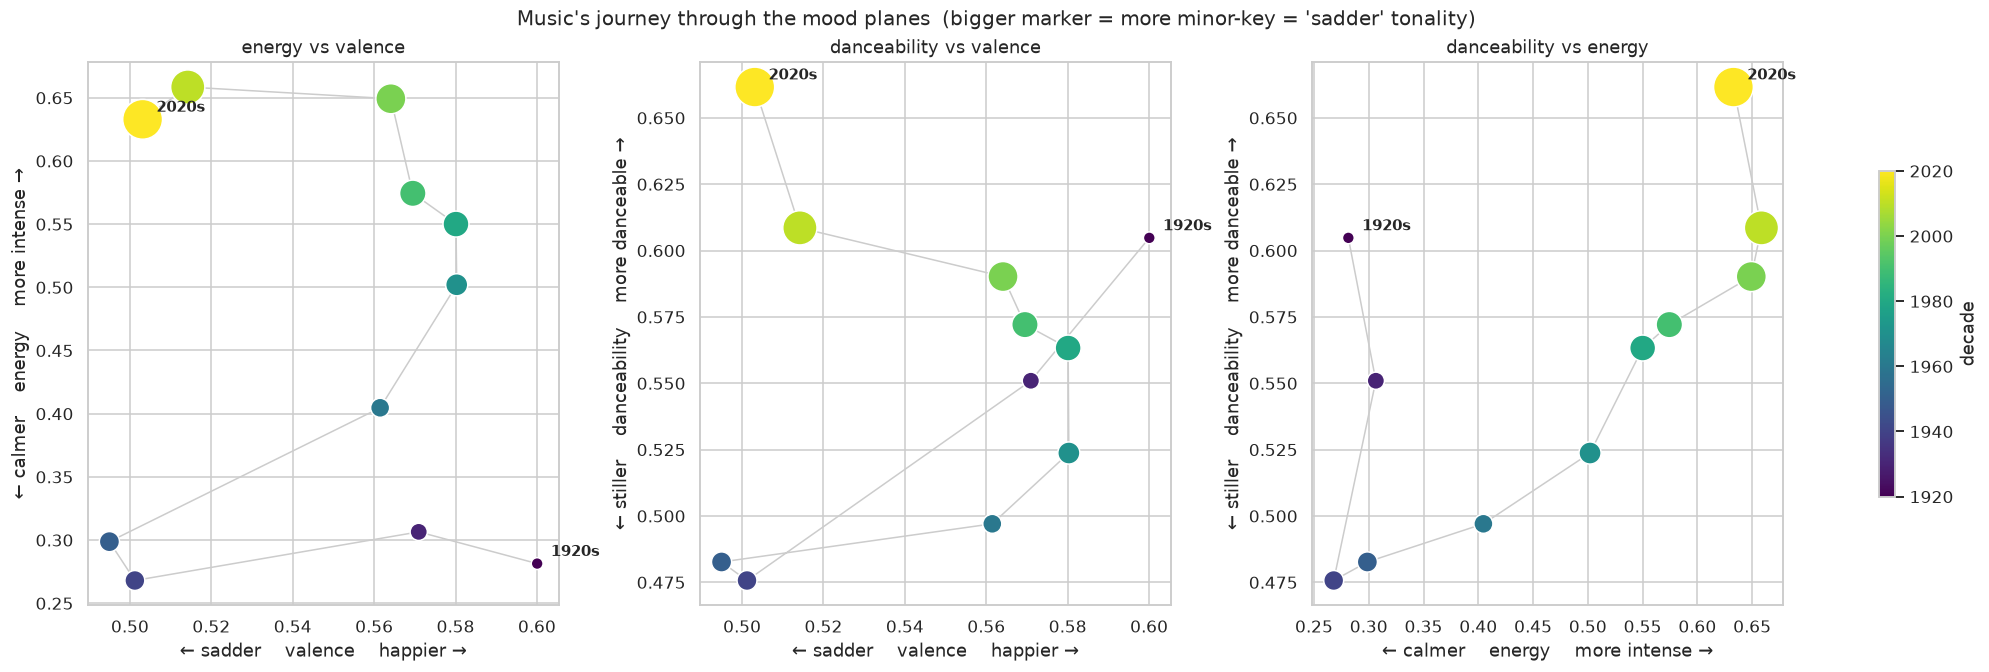

In [10]:
M = me.join(df.groupby('decade')['danceability'].mean())   # reuse Step 6's valence/energy/minor
decs = M.index.to_numpy()
# rescale minor share to a wide dot-size range so the climb is actually visible
mn = (M['minor'] - M['minor'].min()) / (M['minor'].max() - M['minor'].min())
sizes = 60 + mn * 620
axlab = {'valence': '\u2190 sadder    valence    happier \u2192',
         'energy': '\u2190 calmer    energy    more intense \u2192',
         'danceability': '\u2190 stiller    danceability    more danceable \u2192'}
pairs = [('valence','energy'), ('valence','danceability'), ('energy','danceability')]
fig, axes = plt.subplots(1, len(pairs), figsize=(18, 6), layout='constrained')
for ax, (xf, yf) in zip(axes, pairs):
    ax.plot(M[xf], M[yf], '-', color='#ccc', lw=1, zorder=1)
    sc = ax.scatter(M[xf], M[yf], c=decs, cmap='viridis', s=sizes,
                    edgecolor='white', zorder=2)
    for d in (decs[0], decs[-1]):
        ax.annotate(f'{d}s', (M.loc[d, xf], M.loc[d, yf]), textcoords='offset points',
                    xytext=(9, 5), fontsize=10, fontweight='bold')
    ax.set_xlabel(axlab[xf]); ax.set_ylabel(axlab[yf]); ax.set_title(f'{yf} vs {xf}')
fig.colorbar(sc, ax=axes, label='decade', shrink=.6, location='right')
fig.suptitle("Music's journey through the mood planes  "
             "(bigger marker = more minor-key = 'sadder' tonality)", fontsize=13)
plt.show()

## Step 7 — Does music's mood follow the times — real *or* perceived?
There are two ways to read 'the mood of the era': the **objective** economy (the misery index = unemployment + inflation) and how people **feel** — U. Michigan's consumer-sentiment survey. They often diverge: lately people report feeling far worse than the hard numbers alone would predict. Both series (plus FRED-fetched, no-auth) get overlaid on music valence. Because all three *trend*, a raw correlation is misleading — we lean on **year-over-year (detrended)** correlations and a **start-year robustness check** before believing anything.

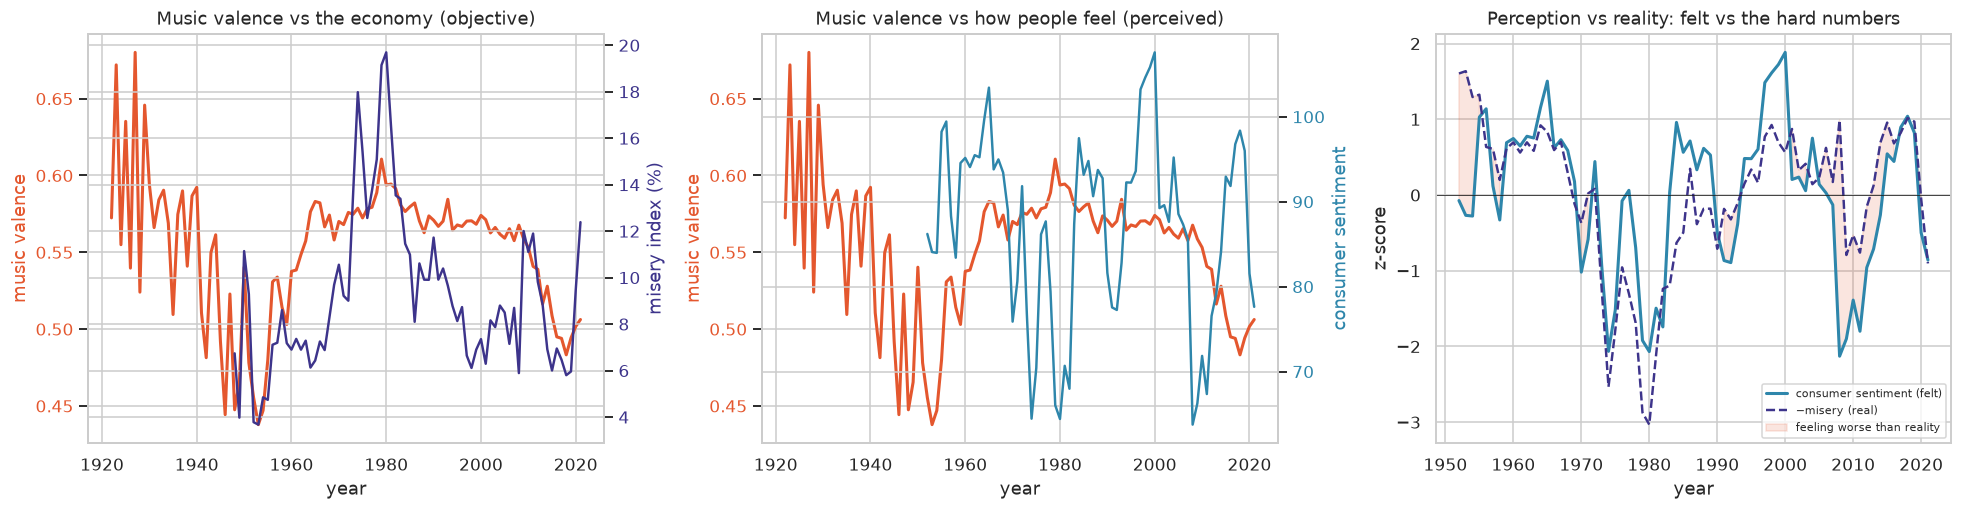

In [11]:
m = load_misery(); sent = load_sentiment()
J = pd.concat([yr['valence'], m['misery'], sent], axis=1)
MIN_TRACKS_YR = 200   # drop thin, volatile early catalog (cf. MIN_N in Step 4)
J = J[J.index.map(n_by_year).fillna(0) >= MIN_TRACKS_YR]
def vs_axis(ax, series, color, ylab):   # music valence (left) vs another series (right)
    ax.plot(J.index, J['valence'], color='#e4572e', lw=2)
    ax.set_ylabel('music valence', color='#e4572e'); ax.tick_params(axis='y', labelcolor='#e4572e')
    axb = ax.twinx(); axb.plot(J.index, J[series], color=color, lw=1.6)
    axb.set_ylabel(ylab, color=color); axb.tick_params(axis='y', labelcolor=color)
    ax.set_xlabel('year')
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
vs_axis(ax[0], 'misery', '#3d348b', 'misery index (%)')
ax[0].set_title('Music valence vs the economy (objective)')
vs_axis(ax[1], 'sentiment', '#2e86ab', 'consumer sentiment')
ax[1].set_title('Music valence vs how people feel (perceived)')
# right: perceived (sentiment) vs reality (-misery), standardized to expose the gap
z = J[['sentiment','misery']].dropna(); z = (z - z.mean())/z.std()
ax[2].plot(z.index, z['sentiment'], color='#2e86ab', lw=2, label='consumer sentiment (felt)')
ax[2].plot(z.index, -z['misery'], color='#3d348b', lw=1.6, ls='--', label='−misery (real)')
ax[2].fill_between(z.index, z['sentiment'], -z['misery'],
                   where=z['sentiment'] < -z['misery'], color='#e4572e', alpha=.15,
                   label='feeling worse than reality')
ax[2].axhline(0, color='k', lw=.5)
ax[2].set_title('Perception vs reality: felt vs the hard numbers')
ax[2].set_ylabel('z-score'); ax[2].set_xlabel('year'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [12]:
def detrended(a, b, lo=None):
    d = J[[a, b]].dropna()
    if lo: d = d[d.index >= lo]
    d = d.diff().dropna()
    return d[a].corr(d[b]), len(d)
print('Detrended (year-over-year) corr of music valence with:')
for b in ['misery', 'sentiment']:
    r, nn = detrended('valence', b); print(f'   {b:9s}: {r:+.2f}  (n={nn})')
print('\nRobustness — valence vs misery by start year (early catalog is thin & volatile):')
for lo in [1948, 1960, 1975]:
    r, nn = detrended('valence', 'misery', lo); print(f'   from {lo}: {r:+.2f}  (n={nn})')
sm = J[['sentiment','misery']].dropna()
print(f'\nPerception vs reality: corr(sentiment, −misery) = {sm.sentiment.corr(-sm.misery):+.2f}'
      '  (they usually agree — but not always)')

Detrended (year-over-year) corr of music valence with:
   misery   : +0.31  (n=73)
   sentiment: -0.07  (n=69)

Robustness — valence vs misery by start year (early catalog is thin & volatile):
   from 1948: +0.31  (n=73)
   from 1960: +0.01  (n=61)
   from 1975: -0.01  (n=46)

Perception vs reality: corr(sentiment, −misery) = +0.66  (they usually agree — but not always)


**Takeaway — honestly, music's mood is its own thing.** Once we detrend *and* drop the thin, volatile early catalog, music valence shows **essentially no year-to-year link to either the economy or public sentiment.** The tempting +0.3 'escapism' signal over the full range turns out to be an artifact of a couple of late-1940s outliers — from **1960 on it's ~0.** What the *human* data does confirm is the intuition behind this question: **perception and reality diverge** — consumer sentiment has stretches (mid-2000s, post-2008, the 2020s) of running well below what misery alone predicts, i.e. people *feeling* worse than the hard numbers say. And yes, over recent decades both public sentiment and music valence drift *down* — but two things trending down together across ~70 noisy years isn't evidence one drives the other. The century-long minor-key rise tracks neither. Music's mood follows a trajectory of its own.

## Verdict
**Mood is not one dial, and the dials disagree.** Over the century: **energy nearly doubles**, **valence sags** (sharply post-2000, and the drop is *real within genres* — the shifting mix even hides part of it), and music **tilts to minor keys** (26% → 45%) on a track almost uncorrelated with valence. Louder, more explicit, and — lately — shorter. And tested against the era's mood — economic *and* perceived — music's year-to-year brightness tracks **neither** robustly: it follows a trajectory of its own (the tempting economic 'escapism' link doesn't survive a robustness check). A rich, multi-threaded 'sound of the times' story — and an honest one, since the threads don't all point the same way.

## Why is music getting *sadder* **and** *more intense*? — hypotheses & outlook
Two trends to explain: valence drifting down (with minor keys climbing) *and* energy nearly doubling. They're statistically independent (decade-level corr ≈ 0), so they likely have *different* causes. Below are candidate drivers — clearly **hypotheses**, not things this dataset can prove. One thing we *can* say: Step 7 already ruled out the tidy 'hard times → sad music' story, so the drivers are cultural/industrial, not the macro-economy.

First, note the two trends increasingly arrive *together* — the 'sad banger' (low-valence yet high-energy) is now a third of tracks:

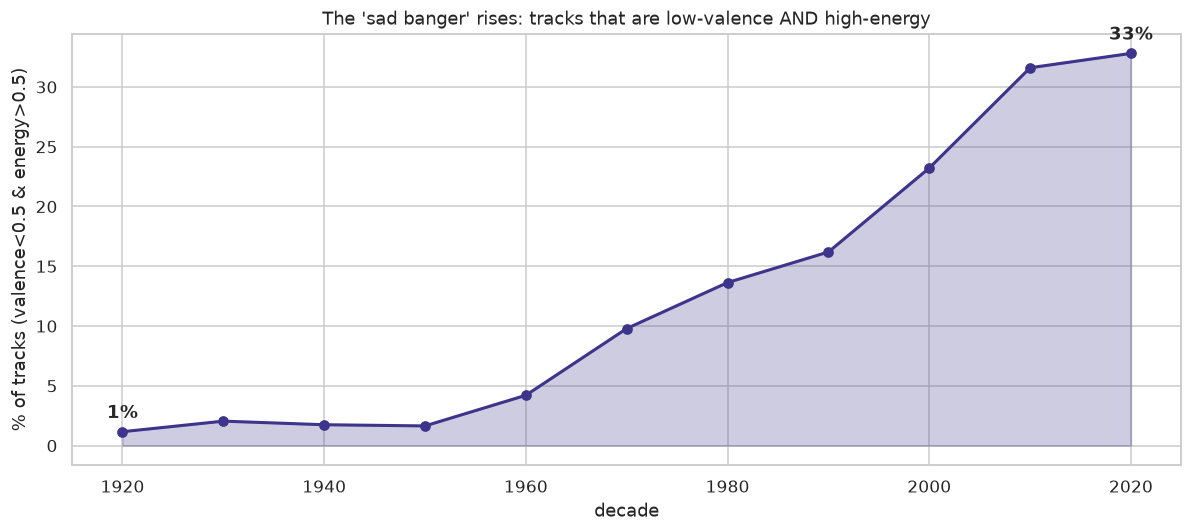

The energy rise is an electrification story — decade-level corr(energy, ...):
   loudness +0.97   acousticness -1.00


In [13]:
V_MAX, E_MIN = 0.5, 0.5   # 'sad banger' = low valence + high energy
share = ((df.valence < V_MAX) & (df.energy > E_MIN)).groupby(df.decade).mean() * 100
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(share.index, share.values, color='#3d348b', alpha=.25)
ax.plot(share.index, share.values, marker='o', color='#3d348b', lw=2)
for x in (share.index[0], share.index[-1]):
    ax.annotate(f'{share[x]:.0f}%', (x, share[x]), textcoords='offset points',
                xytext=(0, 9), ha='center', fontweight='bold')
ax.set_title("The 'sad banger' rises: tracks that are low-valence AND high-energy")
ax.set_xlabel('decade'); ax.set_ylabel(f'% of tracks (valence<{V_MAX} & energy>{E_MIN})')
plt.tight_layout(); plt.show()
g = df.groupby('decade')[['energy','loudness','acousticness']].mean()
print('The energy rise is an electrification story — decade-level corr(energy, ...):')
print(f'   loudness {g.energy.corr(g.loudness):+.2f}   acousticness {g.energy.corr(g.acousticness):+.2f}')

### Why *more energy*? (the better-grounded half)
- **Production electrification.** Acoustic instruments → electric/synth/digital, plus the 'loudness war'. The data backs this hard: decade energy correlates **+0.97** with loudness and **−1.00** with acousticness. Energy is largely a *production* variable — this is the strongest, best-supported driver.
- **The streaming / attention economy.** Playlists and skip-rates reward an immediate hook; arrangements get front-loaded, punchy, dense.
- **Genre shift** toward high-energy styles (crooners → rock → hip-hop/EDM).

### Why *sadder*? (valence down, minor up — more speculative)
- **Genre & aesthetic shift.** Incoming genres (hip-hop/trap, alt/emo, melancholic EDM) lean minor-key and emotionally ambiguous; 'bittersweet' became cool. *But* valence also fell **within** genres (Step 4), so the mix isn't the whole story.
- **The 'sad banger' aesthetic** itself — catharsis you can dance to (minor/low-valence but high-energy). That quadrant grew ~20× (chart above).
- **Mood as a product surface.** Streaming merchandises feelings ('sad', 'chill', lo-fi) as discovery categories, and algorithms reinforce what gets saved.
- **Cultural openness** about mental health / authenticity, amplified by social media.
- **Measurement caveats.** Spotify's valence/energy are algorithmic *estimates*; louder, denser modern production can nudge them, remasters shift old tracks, and the catalog is a snapshot — so part of the 'trend' may be measurement drift, not pure artistic change.

### Outlook
- **Minor keys are still climbing** (45% and no plateau), while **energy has flattened/dipped** in the 2020s (0.63 vs 0.66 in the 2010s — though 2020s is partial data). A tentative prediction: the loudness/energy race is maxing out, but tonal 'darkening' keeps going.
- **To go from correlation to explanation**, the next data to pull: **lyrics sentiment** (do the words match the tonal shift?), per-genre longitudinal deep-dives, **non-US catalogs** (is this global or Anglophone?), listener-behavior data (are sad songs streamed *more*?), and controlling for remaster loudness.